In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "GBP_FX_BoE_10y.csv"
TARGET = "GBP-USD"

## Data Loading and Preprocessing

In [10]:
from fx_forecasting.data.load import load_fx_csv
from fx_forecasting.data.preprocess import prepare_fx_data
from fx_forecasting.data.inspect import inspect_data

df, feature_columns = load_fx_csv(DATA_PATH)

# Assume LSTM model
X_train, y_train, X_test, y_test, scaler = prepare_fx_data(
    df,
    target_col=TARGET,
    test_ratio=0.2,
    add_returns=False,
    add_ma=False,
    add_volatility=False,
    scale=True,
    scaler_type="standard",
    make_windows=True,
    lookback=28
)

print(feature_columns)

['GBP-CNY', 'GBP-USD', 'GBP-EUR', 'GBP-JPY', 'GBP-KRW', 'GBP-CHF']


/Users/apple/COMP0197-group-project/src/fx_forecasting/data/load.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df[date_col], errors="coerce")


In [11]:
# Inspect Data
inspect_data(df)


Shape: (2779, 7)

Columns:
['timestamp', 'GBP-CNY', 'GBP-USD', 'GBP-EUR', 'GBP-JPY', 'GBP-KRW', 'GBP-CHF']

First rows:
   timestamp  GBP-CNY  GBP-USD  GBP-EUR   GBP-JPY    GBP-KRW  GBP-CHF
0 2015-01-02   9.5476   1.5388   1.2790  184.9638  1702.0821   1.5373
1 2015-01-05   9.4794   1.5240   1.2767  182.2552  1690.7256   1.5338
2 2015-01-06   9.4244   1.5170   1.2727  180.0831  1670.4901   1.5287
3 2015-01-07   9.3582   1.5063   1.2762  179.9275  1661.7351   1.5327
4 2015-01-08   9.3724   1.5082   1.2789  180.5014  1654.6764   1.5363

Data types:
timestamp    datetime64[us]
GBP-CNY             float64
GBP-USD             float64
GBP-EUR             float64
GBP-JPY             float64
GBP-KRW             float64
GBP-CHF             float64
dtype: object

Missing values:
timestamp    0
GBP-CNY      0
GBP-USD      0
GBP-EUR      0
GBP-JPY      0
GBP-KRW      0
GBP-CHF      0
dtype: int64

Date range:
Start: 2015-01-02 00:00:00
End: 2025-12-31 00:00:00

Observed time gaps:
timestamp
1 days

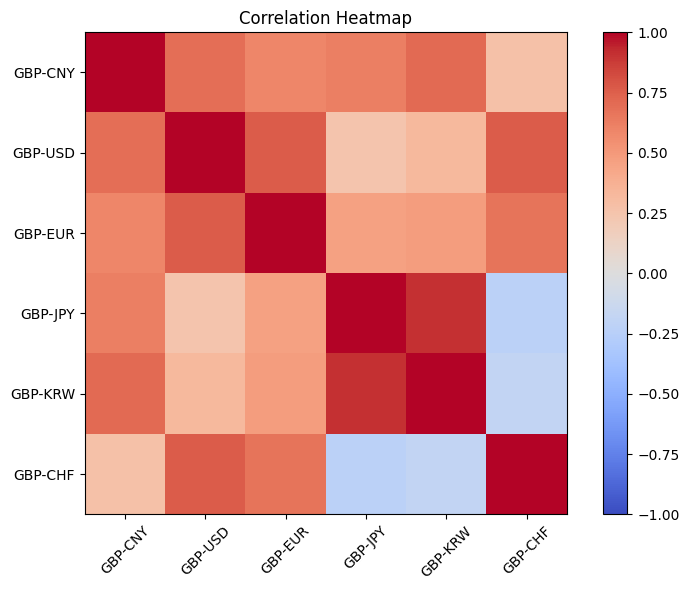

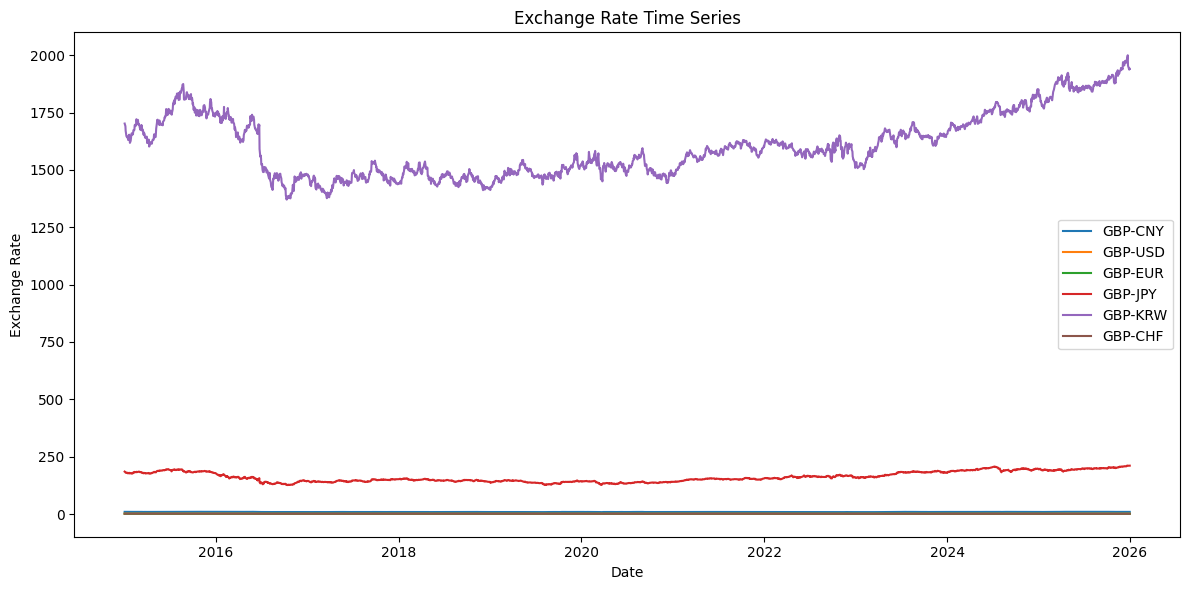

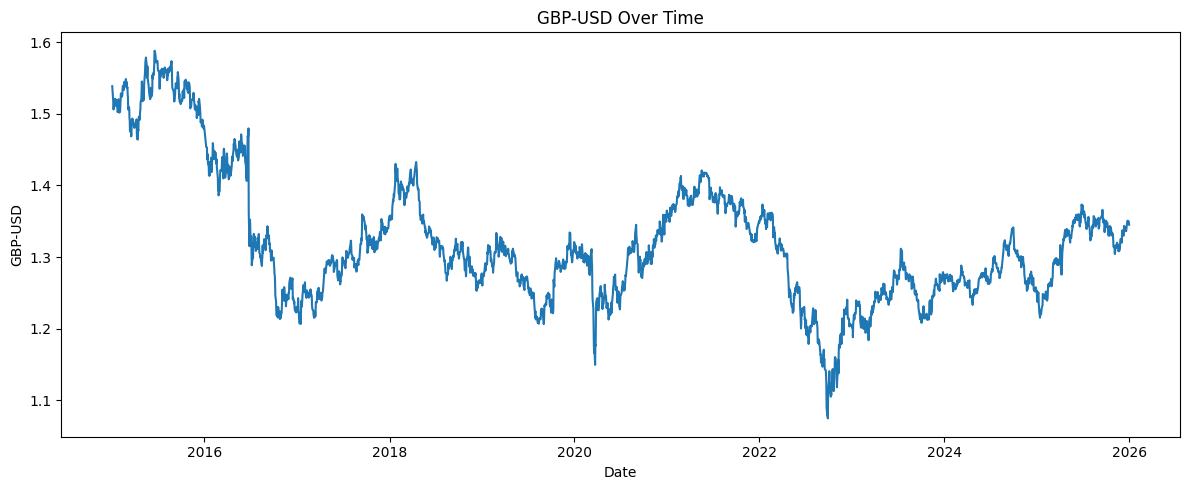

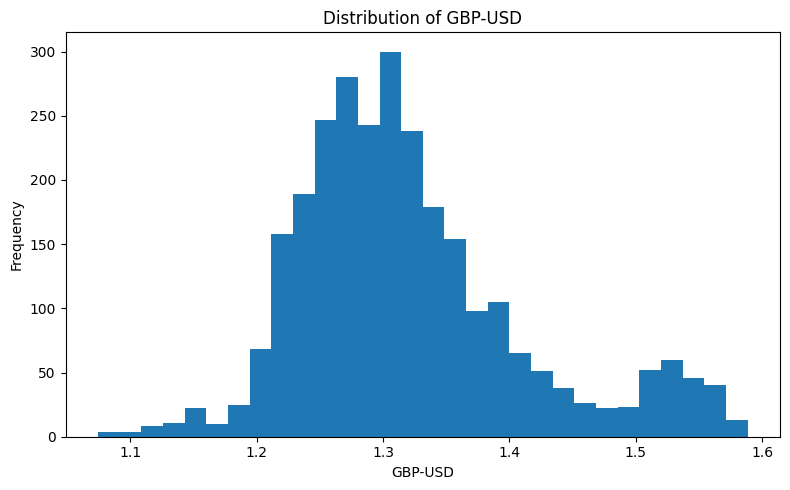

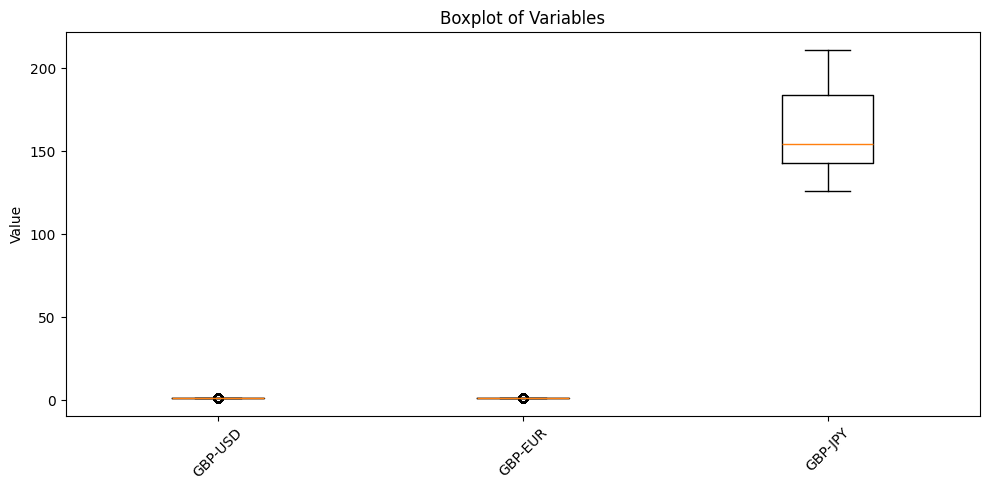

In [12]:
# visualisations

from fx_forecasting.visualization.plots import (
    plot_all_series,
    plot_target_series,
    plot_histogram,
    plot_boxplot,
    plot_correlation_heatmap
)

plot_correlation_heatmap(df)
plot_all_series(df)
plot_target_series(df, "GBP-USD")
plot_histogram(df, "GBP-USD")
plot_boxplot(df, cols=["GBP-USD", "GBP-EUR", "GBP-JPY"])

## Model Training

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Hyperparameters
HIDDEN_DIM = 64
NUM_LAYERS = 2
LR = 0.001
EPOCHS = 20
BATCH_SIZE = 64


In [14]:
# Data loaders
from torch.utils.data import TensorDataset, DataLoader

# convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# datasets
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_test_t, y_test_t)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [15]:
from fx_forecasting.models.baseline import DeterministicLSTM
from fx_forecasting.training.train import train_model


model = DeterministicLSTM(
    input_dim=X_train.shape[2],
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS
)

# Optimizer and loss
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss() 
device = "cuda" if torch.cuda.is_available() else "cpu"

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    device=device,
    save_path="best_baseline_model.pt",
    early_stopping_patience=7
)

Epoch 1/20 [Val]: 100%|██████████| 17/17 [00:00<00:00, 374.03it/s]


Epoch 1/20 | Train Loss: 0.3011 | Val Loss: 0.3629 | Train MAE: 0.4116 | Val MAE: 0.4884 | Train RMSE: 0.5112 | Val RMSE: 0.5241
Saved best model at epoch 1 with val loss 0.3629


Epoch 2/20 [Val]: 100%|██████████| 17/17 [00:00<00:00, 347.94it/s]


Epoch 2/20 | Train Loss: 0.1034 | Val Loss: 0.2941 | Train MAE: 0.2551 | Val MAE: 0.4687 | Train RMSE: 0.3191 | Val RMSE: 0.4918
Saved best model at epoch 2 with val loss 0.2941


Epoch 3/20 [Val]: 100%|██████████| 17/17 [00:00<00:00, 374.30it/s]


...

Epoch 8/20 | Train Loss: 0.0477 | Val Loss: 0.1258 | Train MAE: 0.1670 | Val MAE: 0.2710 | Train RMSE: 0.2156 | Val RMSE: 0.2955


Epoch 9/20 [Val]: 100%|██████████| 17/17 [00:00<00:00, 352.99it/s]


Epoch 9/20 | Train Loss: 0.0403 | Val Loss: 0.2084 | Train MAE: 0.1548 | Val MAE: 0.3766 | Train RMSE: 0.1981 | Val RMSE: 0.4008


Epoch 10/20 [Val]: 100%|██████████| 17/17 [00:00<00:00, 357.77it/s]

Epoch 10/20 | Train Loss: 0.0391 | Val Loss: 0.2218 | Train MAE: 0.1524 | Val MAE: 0.4199 | Train RMSE: 0.1952 | Val RMSE: 0.4394
Early stopping at epoch 10
Best model was from epoch 3 with val loss 0.1048


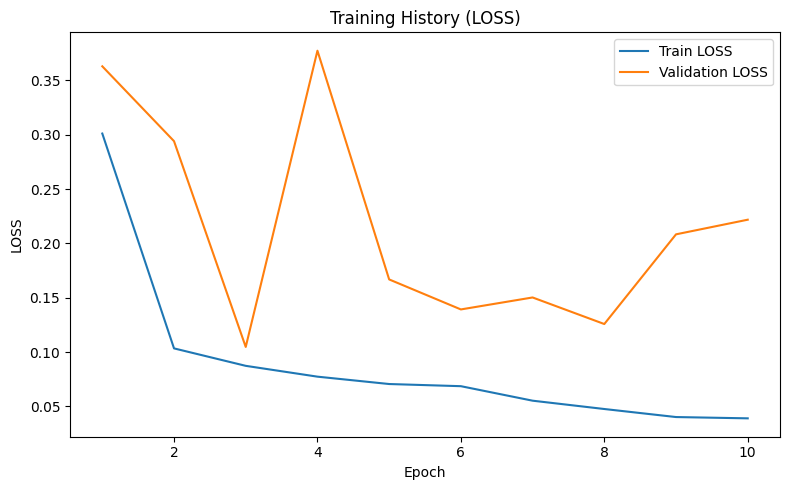

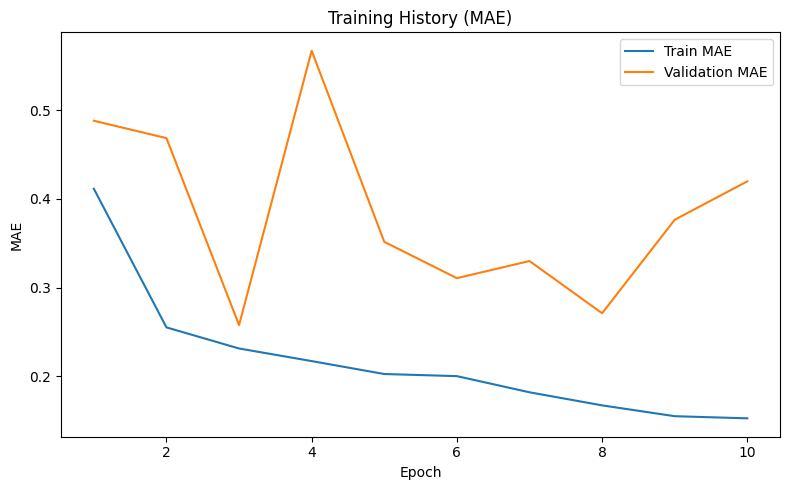

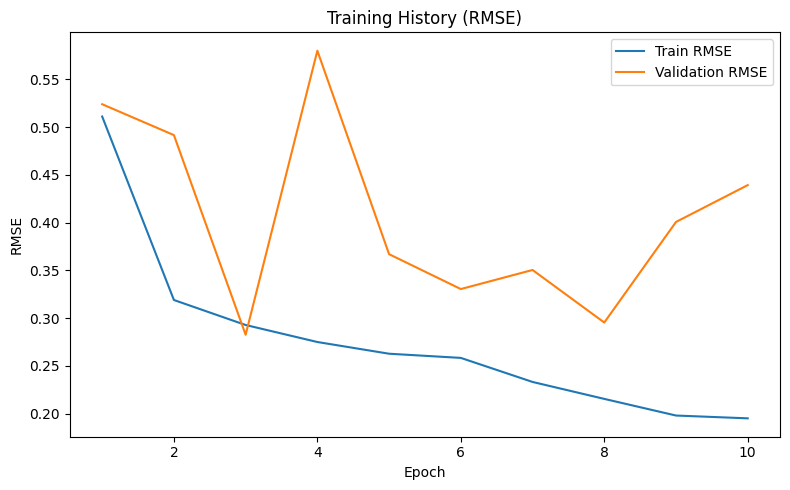

In [16]:
from fx_forecasting.visualization.plots import plot_training_history

plot_training_history(history, metric="loss")
plot_training_history(history, metric="mae")
plot_training_history(history, metric="rmse")

## Evaluation 


Evaluation metrics:
MSE: 0.208641
RMSE: 0.456773
MAE: 0.408148


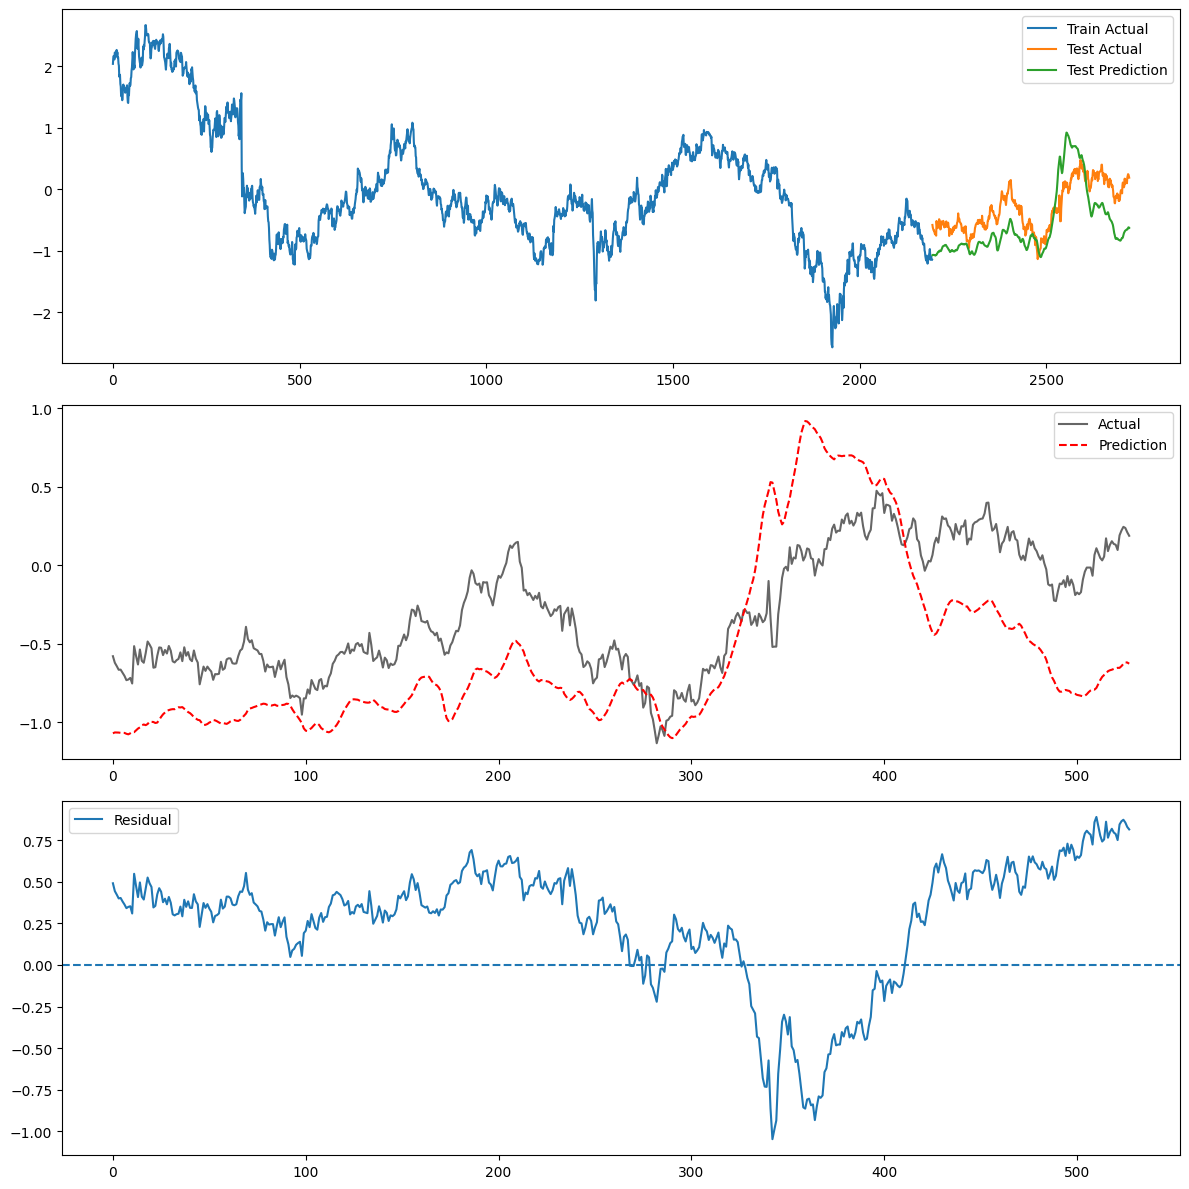

In [17]:
from fx_forecasting.training.evaluate import evaluate_model
from fx_forecasting.visualization.plots import plot_predictions
from fx_forecasting.data.preprocess import inverse_transform_target


preds, targets, metrics = evaluate_model(
    model,
    val_loader,
    device=device
)

# inverse transform
preds_original = inverse_transform_target(
    preds,
    scaler=scaler,
    feature_columns=feature_columns,
    target_col="GBP-USD",
)

targets_original = inverse_transform_target(
    targets,
    scaler=scaler,
    feature_columns=feature_columns,
    target_col="GBP-USD",
)

y_train_original = inverse_transform_target(
    y_train,
    scaler=scaler,
    feature_columns=feature_columns,
    target_col="GBP-USD",
)

plot_predictions(
    preds=preds,
    targets=targets,
    train_targets=y_train
)